In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov






/tmp/ipykernel_1975348/4202627634.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
def get_samps(fname, acorr_max = 0.075, acorr_min = 0.0075):
    df = pk.load(open(fname,'rb'))
    sig8 = df['sigma8']
    nchains = 64
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    print(len(ind_del))
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys





In [3]:
# ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# # samps_all = get_MCsamps(ldir + 'mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps_gty = get_MCsamps(ldir + 'mcmc_v9_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps_xipm = get_MCsamps(ldir + 'mcmc_v9_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# samps, keys = get_samps(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# nsamp_tot = samps.shape[0]
# indsel = np.sort(np.random.randint(0, nsamp_tot, 64))
# indsel

ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Feb/'
samps, keys = get_samps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

nsamp_tot = samps.shape[0]
# indsel = np.sort(np.random.randint(0, nsamp_tot, 64))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
indsel = np.sort(np.random.randint(0, nsamp_tot, 512))



13
(204000, 22) (51, 4000, 22)


In [4]:
# samps.shape




In [5]:
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

fb_norm_all_samp = []

for map_ind in tqdm(indsel):
# for map_ind in tqdm(indsel[:1]):    
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']
    
    cosmop = sim_params_dict['cosmo']
    params = {'w0':-1.0 ,'flat': True, 'H0': cosmop['H0'], 'Om0': cosmop['Om0'], 'Ob0': cosmop['Ob0'], 'sigma8':cosmop['sigma8'] ,'ns': cosmop['ns']}
    cosmology_colossus.addCosmology('myCosmo', params)
    cosmology_colossus.setCosmology('myCosmo')
    cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')
    
    h = params['H0']/100.
    z = 0.0
    M500c_min_wh = 6e13*h
    M500c_max_wh = 2e14*h
    c500c_min_wh = concentration.concentration(M500c_min_wh, '500c', z, model = 'bhattacharya13')
    c500c_max_wh = concentration.concentration(M500c_max_wh, '500c', z, model = 'bhattacharya13')
    M200c_min_wh, _, _ = mass_defs.changeMassDefinition(M500c_min_wh, c500c_min_wh, z, '500c', '200c')
    M200c_max_wh, _, _ = mass_defs.changeMassDefinition(M500c_max_wh, c500c_max_wh, z, '500c', '200c')
    
    halo_params_dict['lg10_Mmin'] = np.log10(M200c_min_wh)
    halo_params_dict['lg10_Mmax'] = np.log10(M200c_max_wh)
    
    halo_params_dict['zmin'] = 0.001
    halo_params_dict['zmax'] = 0.01
    halo_params_dict['nz'] = 3

    halo_params_dict['nr'] = 32
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    M200c_array = profiles_test.M_array
    conc_array = profiles_test.conc_Mz_mat[0,:]
    M500c_array, R500c_array, _ = mass_defs.changeMassDefinition(M200c_array, conc_array, z, '200c', '500c')
    R500c_array /= 1000.
    
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,0,:]
    rho_tot_mat_z0 = rho_tot_mat[:,0,:]
    
    fb_array = np.zeros(len(M500c_array))
    for jM in range(len(M500c_array)):
            r500_jM = R500c_array[jM]
            r_array_jM = np.logspace(-3, np.log10(r500_jM), 100)
            rho_baryon_jM = rho_baryon_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
            rhob_jM = np.exp(interprho(np.log(r_array_jM)))
            rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
            rho_tot_jM = rho_tot_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
            rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
            rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
            fb_array[jM] = rhob_int_jM/rhotot_int_jM
    
    fb_bar = np.trapezoid(fb_array * profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))/np.trapezoid(profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))
    fb_bar_norm = fb_bar/(cosmop['Ob0']/cosmop['Om0'])

    fb_norm_all_samp.append(fb_bar_norm)
    
    



  0%|          | 0/512 [00:00<?, ?it/s]

100%|██████████| 512/512 [59:35<00:00,  6.98s/it]


In [8]:
# halo_params_dict.keys()
# sim_params_dict['cosmo']
fb_norm_all = np.array(fb_norm_all_samp)


In [14]:
fb_mean = np.mean(fb_norm_all)
fb_std = np.std(fb_norm_all)

# DeltaP_mean = -0.05
# DeltaP_std = 0.02
# saved = {'Pmm_ratio_all_samp': Pmm_ratio_all_samp, 'Pmin': Pmin, 'Pmax': Pmax, 'k_array': np.array(Pkz_test.kPk_array)}
# pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_all_probes.pkl','wb'))
df = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_all_probes_widemuej.pkl','rb'))
Pmm_ratio_all_samp = df['Pmm_ratio_all_samp']
Pmin = df['Pmin']
Pmax = df['Pmax']
k_array = df['k_array']
indsel = np.argmin(np.abs(k_array - 0.5))
print(indsel)
print(Pmin[indsel], Pmax[indsel])

Pmin = Pmin[indsel] - 1
Pmax = Pmax[indsel] - 1
DeltaP_mean = 0.5*(Pmin + Pmax)
DeltaP_std = 0.5*(Pmax - Pmin)

# np.float64(0.882593105319559), np.float64(0.9585439801058012)


57
0.9181625045794283 0.9789893968181687


In [10]:
saved = {'fb_norm_all': fb_norm_all, 'fb_mean': fb_mean, 'fb_std': fb_std}
pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/fbnorm_plot_data_nsamps_512_v10_all_probes_widemuej.pkl','wb'))



In [11]:
import matplotlib
%matplotlib inline



In [12]:
sims_data =  {
    "Cosmo-OWLS": [
        [0.2875726880009398, -0.12005868438055672],
        [0.29108200327863604, -0.10038072760088215],
        [0.40693853358465987, -0.05633219951621431],
        [0.40684028130056127, -0.04568410822702686],
        [0.48237279266098154, -0.03152002691258217],
        [0.6261607386008662, -0.014538668147570655],
        [0.6206094845492944, -0.012921510308480127],
        [0.8927384086333856, -0.004893657921857392],
        [0.8853588077298917, -0.005129410005713576],
        [0.8669108734307669, -0.005834530338062603],
    ],
    "BAHAMAS": [
        [0.42899617136479906, -0.04682869393879523],
        [0.5653062641170911, -0.019434995968452468],
        [0.5818959486952203, -0.017342062123210496],
        [0.5681064542139017, -0.022905597710294587],
        [0.6676701927133117, -0.013125757583848173],
    ],
    "Illustris": [
        [0.3894090445499352, -0.056573825377924214],
    ],
    "Illustris TNG-300": [
        [0.8696533937086501, -0.003055165453642532],
    ],
    "EAGLE": [
        [0.9028519861378843, -0.0009526199719126563],
    ],
}

all_sims = list(sims_data.keys())


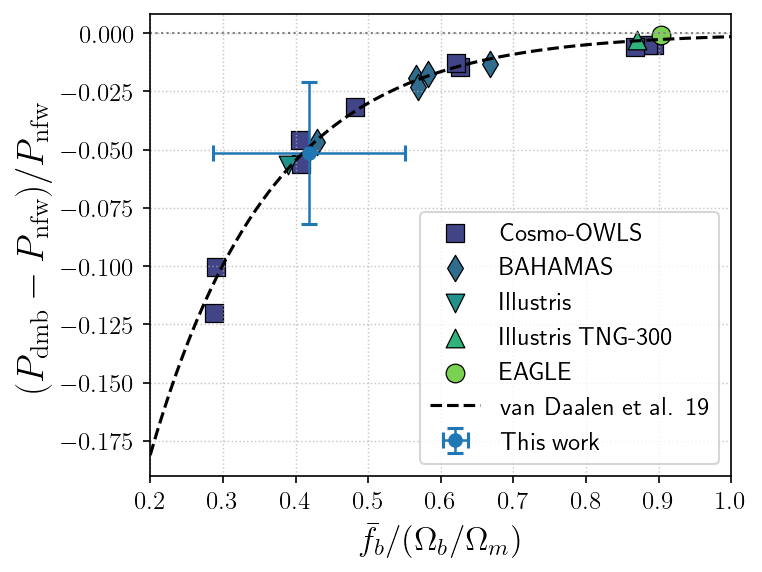

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5, 4), dpi=150)

# Improved error bars with better capsize and marker style
plt.errorbar(
    fb_mean, DeltaP_mean, 
    xerr=fb_std, yerr=DeltaP_std, 
    fmt='o', capsize=4, capthick=1.5, elinewidth=1.2, 
    label='This work', color='tab:blue', markersize=6
)

# # Define colors for different simulations
# colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(all_sims)))

# # Loop through simulations and plot them with improved markers
# for i, sim in enumerate(all_sims):
#     data_sim = np.array(sims_data[sim])
#     plt.scatter(
#         data_sim[:, 0], data_sim[:, 1], 
#         marker='s', s=40, color=colors[i], 
#         label=sim, edgecolor='black', linewidth=0.6
#     )
# Define different markers and colors for simulations
markers = ['s', 'd', 'v', '^', 'o', 'p', '*', 'X']  # Different marker types
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(all_sims)))

# Loop through simulations and plot them with distinct markers
for i, sim in enumerate(all_sims):
    data_sim = np.array(sims_data[sim])
    plt.scatter(
        data_sim[:, 0], data_sim[:, 1], 
        marker=markers[i % len(markers)], s=80, 
        color=colors[i], label=sim, 
        edgecolor='black', linewidth=0.6
    )

# van Daalen et al. 2019 curve
fb_array = np.linspace(0.2, 1.1, 100)
VD_curve = -1 * np.exp(-5.990 * fb_array - 0.5107)
plt.plot(fb_array, VD_curve, ls='--', color='black', label='van Daalen et al. 19', linewidth=1.5)

# Add horizontal reference line
plt.axhline(0.0, ls=':', color='gray', linewidth=1)

# Improve axis limits and labels
plt.xlim(0.2, 1.0)
plt.xlabel(r'$\bar{f}_b/(\Omega_b/\Omega_m)$', fontsize=16)
# plt.ylabel(r'$\Delta P$', fontsize=16)
plt.ylabel(r'$(P_{\rm dmb}-P_{\rm nfw})/P_{\rm nfw}$', fontsize=18)

# Improve legend
plt.legend(fontsize=12, frameon=True, loc='best')

# General plot aesthetics
plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(sdir + 'VD19_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
plt.show()


(10, 2)
(5, 2)
(1, 2)
(1, 2)
(1, 2)


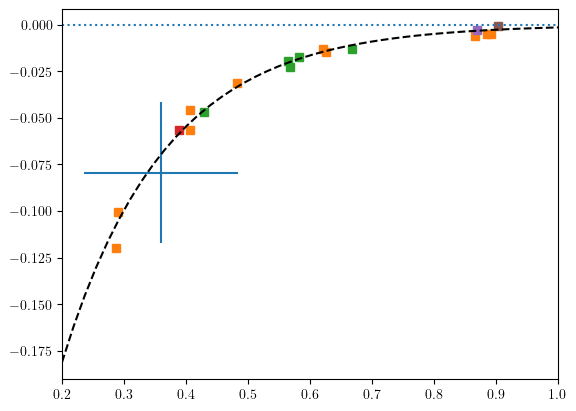

In [30]:
pl.figure()
pl.errorbar(fb_mean,DeltaP_mean, xerr=fb_std, yerr=DeltaP_std, label='This work')
for sim in all_sims:
    data_sim = np.array(sims_data[sim])
    print(data_sim.shape)
    
    pl.plot(data_sim[:,0], data_sim[:,1], ls='', marker='s', legend=sim)

fb_array = np.linspace(0.2, 1.1)
VD_curve = -1*np.exp(-5.990*fb_array - 0.5107)
pl.plot(fb_array, VD_curve, ls='--', color='k', label='van Daalen et al. 19')
pl.axhline(0.0, ls=':')
pl.xlim(0.2, 1.0)
pl.legend()
pl.show()


In [ ]:
rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(self.cosmo_jax,self.scale_fac_a_array[jz]) * 1e9
rho_treshold = mdef_delta * rho_c_z
R = (self.M_array[jM] * 3.0 / 4.0 / jnp.pi / rho_treshold)**(1.0 / 3.0)
# convert to comoving coordinates
R500c *= (1 + self.z_array[jz])
